Week2 EDA

In [6]:
import pandas as pd
df_filtered = pd.read_csv('data_combined.csv')

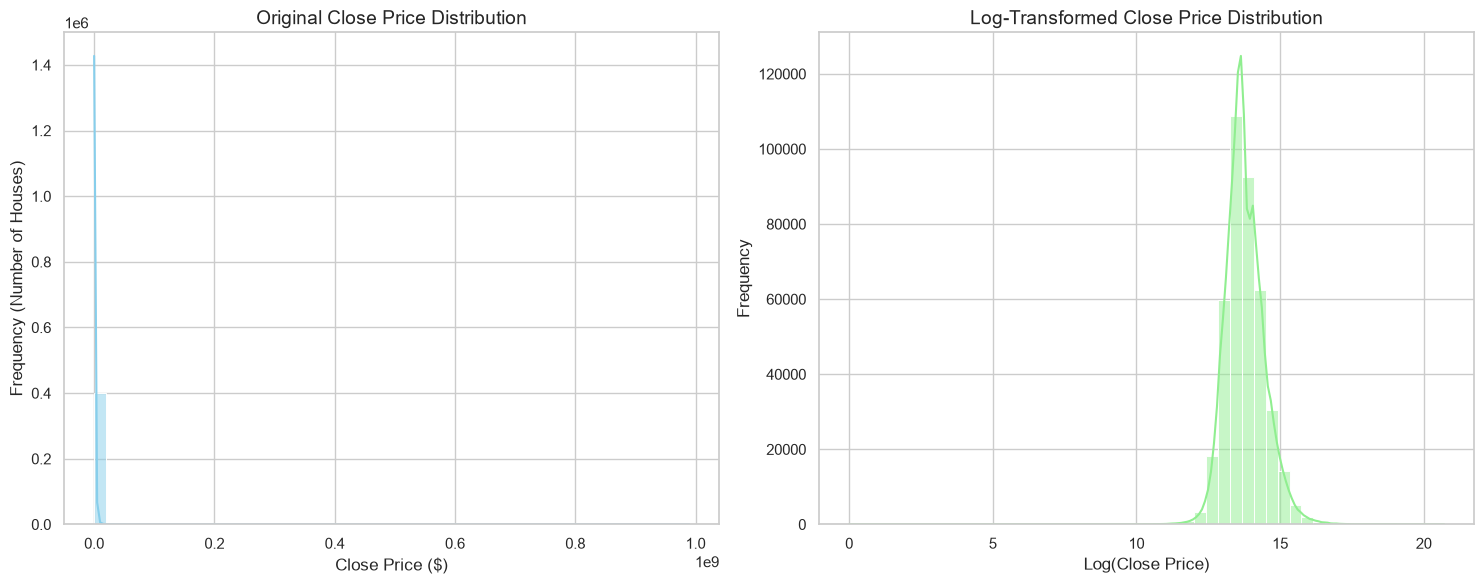

In [3]:
#Analyze the distribution of close_price( target variable)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

df_filtered = pd.read_csv('data_combined.csv')
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(df_filtered['ClosePrice'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Original Close Price Distribution', fontsize=14)
axes[0].set_xlabel('Close Price ($)')
axes[0].set_ylabel('Frequency (Number of Houses)')

sns.histplot(np.log1p(df_filtered['ClosePrice']), bins=50, kde=True, ax=axes[1], color='lightgreen')
axes[1].set_title('Log-Transformed Close Price Distribution', fontsize=14)
axes[1].set_xlabel('Log(Close Price)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

save house between  365,000 dollars to 3,150,000 dollars


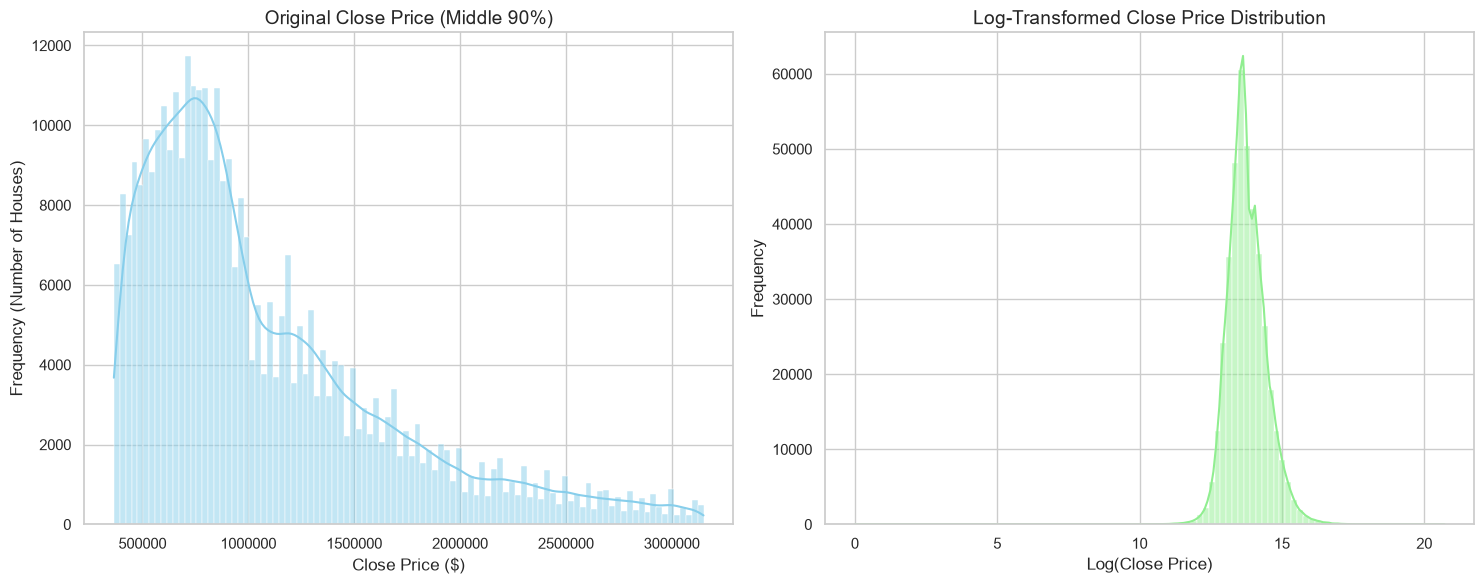

In [ ]:
##Analyze the distribution of close_price without extreme value
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ---- cut top 5% and bottom 5%----
lower_bound = df_filtered['ClosePrice'].quantile(0.05) # 底部 5% 的分界线
upper_bound = df_filtered['ClosePrice'].quantile(0.95) # 顶部 5% (也就是95分位) 的分界线

print(f"save house between  {lower_bound:,.0f} dollars to {upper_bound:,.0f} dollars")


normal_price_mask = (df_filtered['ClosePrice'] >= lower_bound) & (df_filtered['ClosePrice'] <= upper_bound)
normal_prices = df_filtered.loc[normal_price_mask, 'ClosePrice']


sns.histplot(x=normal_prices, bins=100, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Original Close Price (Middle 90%)', fontsize=14)
axes[0].set_xlabel('Close Price ($)')
axes[0].set_ylabel('Frequency (Number of Houses)')
axes[0].ticklabel_format(style='plain', axis='x') 


sns.histplot(x=np.log1p(df_filtered['ClosePrice']), bins=100, kde=True, ax=axes[1], color='lightgreen')
axes[1].set_title('Log-Transformed Close Price Distribution', fontsize=14)
axes[1].set_xlabel('Log(Close Price)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

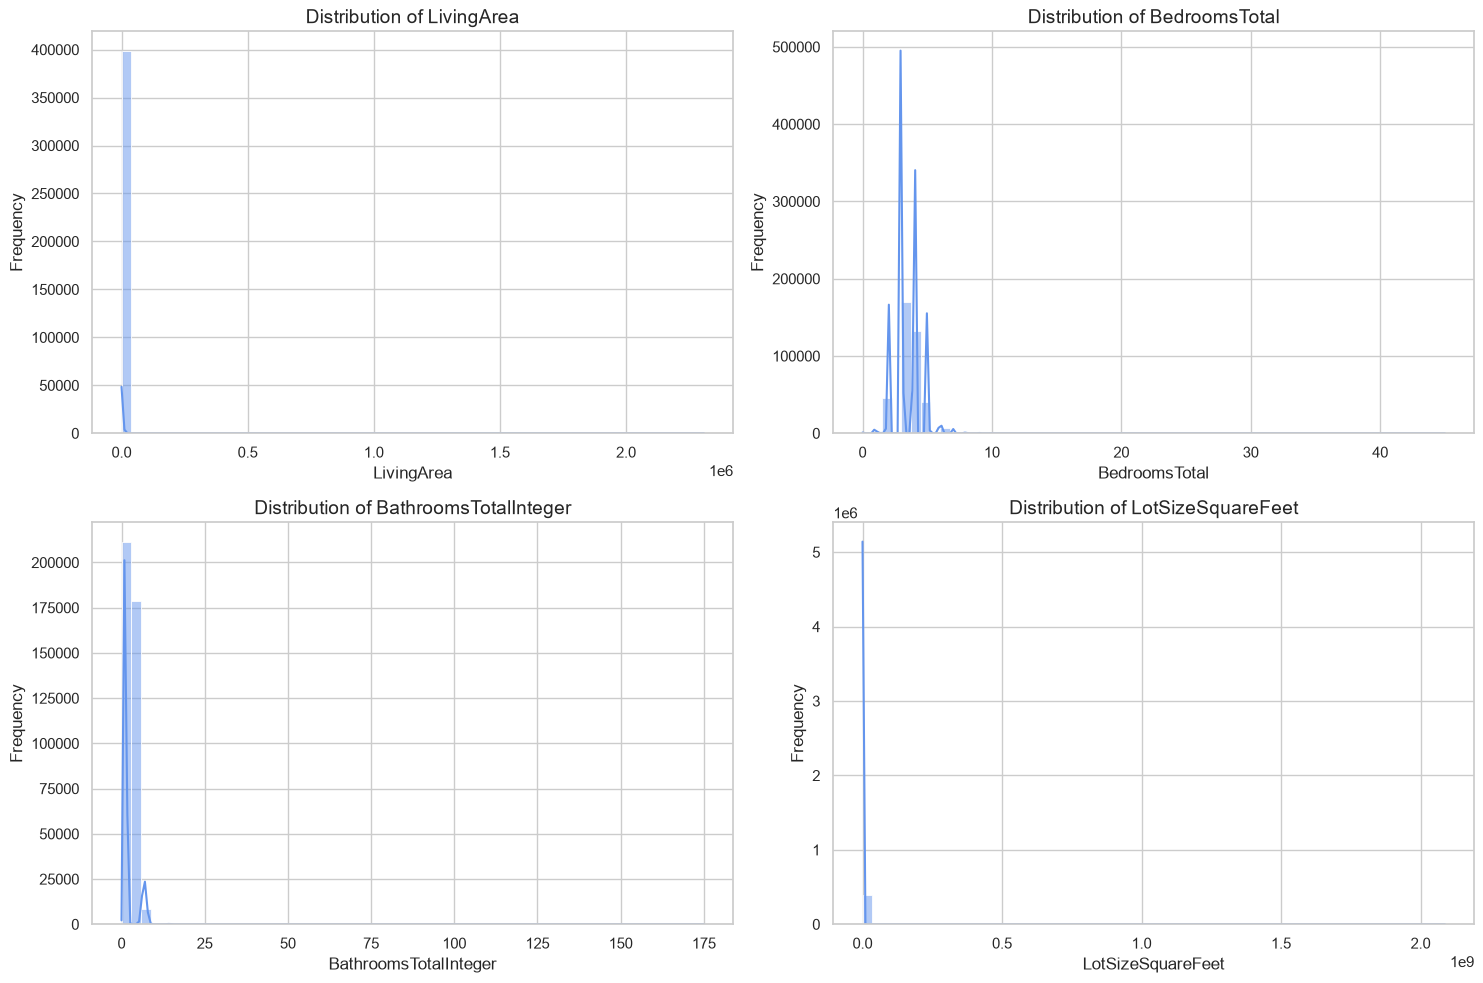

In [ ]:
#plot distribution of LivingArea, BedroomsTotal, BathroomsTotalInteger, LotSizeSquareFeet

features = ['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeSquareFeet']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten() 

for i, feature in enumerate(features):
    sns.histplot(df_filtered[feature].dropna(), bins=60, kde=True, ax=axes[i], color='cornflowerblue')
    axes[i].set_title(f'Distribution of {feature}', fontsize=14)
    axes[i].set_ylabel('Frequency')
    
    if feature == 'LotSizeSquareFeet':
        axes[i].ticklabel_format(style='sci', axis='x', scilimits=(0,0))

plt.tight_layout()
plt.show()

========= 📊 核心 80% 数据分布体检 =========
🔸 【LivingArea】: 保留范围 960.0 到 3801.0
🔸 【BedroomsTotal】: 保留范围 2.0 到 5.0
🔸 【BathroomsTotalInteger】: 保留范围 1.0 到 5.0
🔸 【LotSizeSquareFeet】: 保留范围 3250.0 到 49478.5


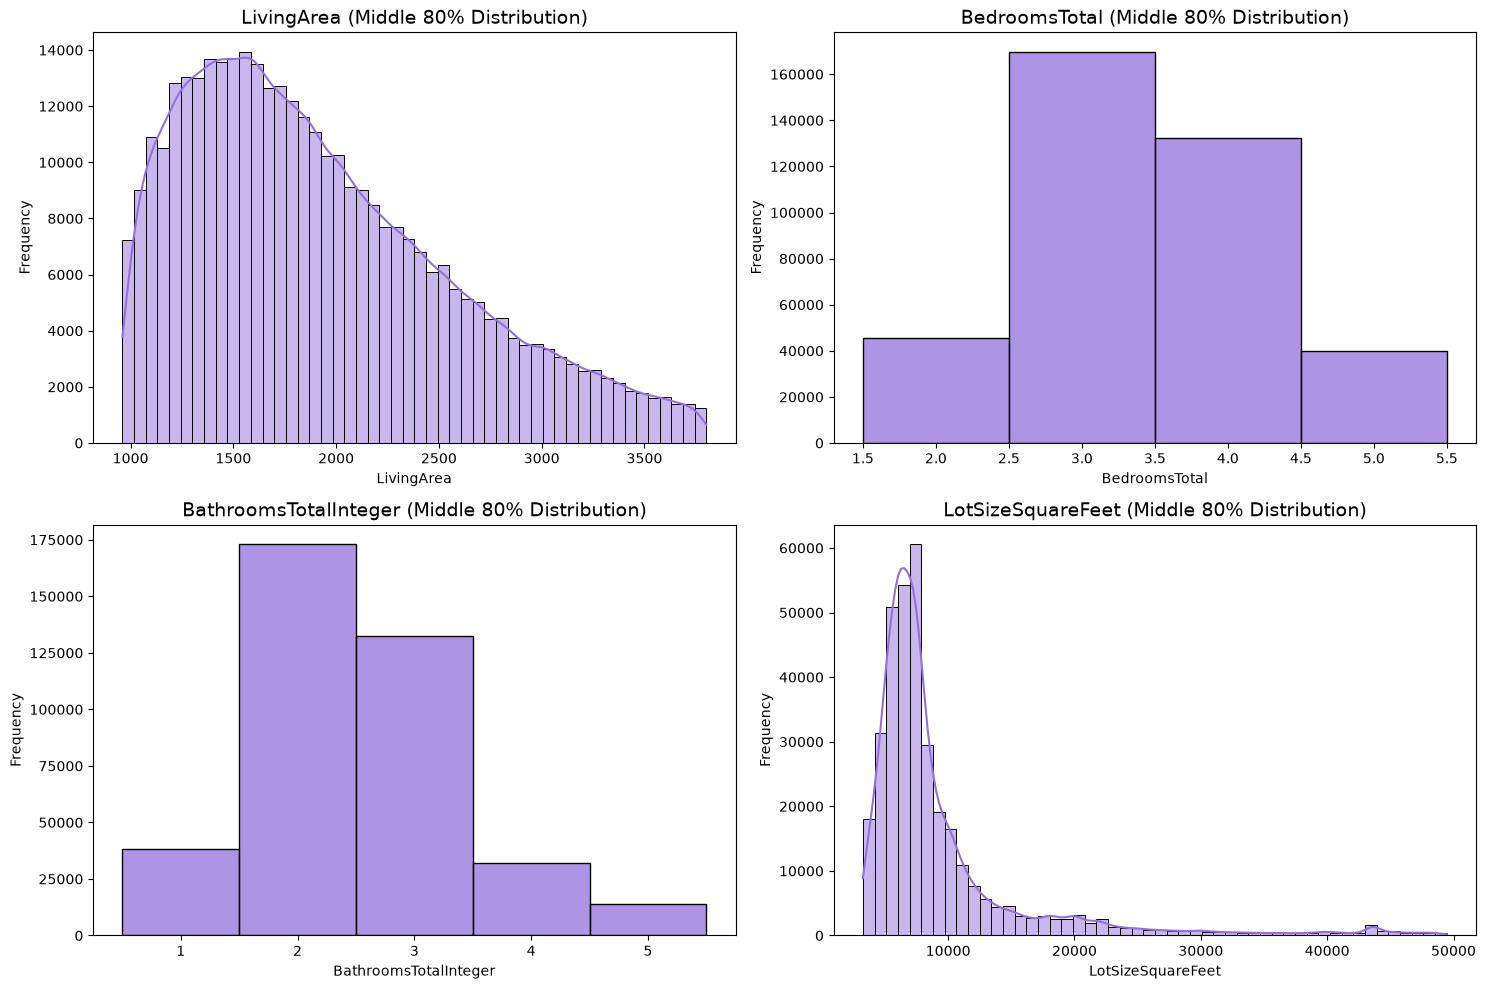

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

features = ['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeSquareFeet']
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

print("========= 📊 核心 80% 数据分布体检 =========")

for i, feature in enumerate(features):

    lower_bound = df_filtered[feature].quantile(0.05)
    upper_bound = df_filtered[feature].quantile(0.95)
    

    core_data = df_filtered[(df_filtered[feature] >= lower_bound) & 
                            (df_filtered[feature] <= upper_bound)][feature]
    
    print(f"🔸 【{feature}】: 保留范围 {lower_bound} 到 {upper_bound}")
    
    # 开始画图
    if feature in ['BedroomsTotal', 'BathroomsTotalInteger']:
        # 整数型的变量依然用离散柱状图更清晰
        sns.histplot(core_data, discrete=True, ax=axes[i], color='mediumpurple')
    else:
        sns.histplot(core_data, bins=50, kde=True, ax=axes[i], color='mediumpurple')
    
    axes[i].set_title(f'{feature} (Middle 80% Distribution)', fontsize=14)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [11]:
# report problems

for feature in features:
    min_val = df_filtered[feature].min()
    max_val = df_filtered[feature].max()
    zero_or_neg_count = (df_filtered[feature] <= 0).sum()
    missing_count = df_filtered[feature].isna().sum()
    
    print(f"🔸 【{feature}】")
    print(f"   -> range: {min_val} to {max_val}")
    print(f"   -> value (<=0): {zero_or_neg_count}")
    print(f"   -> NaN:  {missing_count}\n")

🔸 【LivingArea】
   -> range: 0.0 to 2308680.0
   -> value (<=0): 158
   -> NaN:  210

🔸 【BedroomsTotal】
   -> range: 0.0 to 45.0
   -> value (<=0): 224
   -> NaN:  0

🔸 【BathroomsTotalInteger】
   -> range: 0.0 to 175.0
   -> value (<=0): 167
   -> NaN:  75

🔸 【LotSizeSquareFeet】
   -> range: 0.0 to 2087220960.0
   -> value (<=0): 215
   -> NaN:  6826



In [15]:

#Multivariate 5% Trimming)

print(f"original data number: {len(df_filtered)}")

price_lower = df_filtered['ClosePrice'].quantile(0.05)
price_upper = df_filtered['ClosePrice'].quantile(0.95)
cond_price = (df_filtered['ClosePrice'] >= price_lower) & (df_filtered['ClosePrice'] <= price_upper)

area_lower = df_filtered['LivingArea'].quantile(0.05)
area_upper = df_filtered['LivingArea'].quantile(0.95)
cond_area = (df_filtered['LivingArea'] >= area_lower) & (df_filtered['LivingArea'] <= area_upper)


beds_lower = df_filtered['BedroomsTotal'].quantile(0.05)
beds_upper = df_filtered['BedroomsTotal'].quantile(0.95)
cond_beds = (df_filtered['BedroomsTotal'] >= beds_lower) & (df_filtered['BedroomsTotal'] <= beds_upper)


baths_lower = df_filtered['BathroomsTotalInteger'].quantile(0.05)
baths_upper = df_filtered['BathroomsTotalInteger'].quantile(0.95)
cond_baths = (df_filtered['BathroomsTotalInteger'] >= baths_lower) & (df_filtered['BathroomsTotalInteger'] <= baths_upper)
lot_lower = df_filtered['LotSizeSquareFeet'].quantile(0.05)
lot_upper = df_filtered['LotSizeSquareFeet'].quantile(0.95)
cond_lot = (df_filtered['LotSizeSquareFeet'] >= lot_lower) & (df_filtered['LotSizeSquareFeet'] <= lot_upper)


final_mask = cond_price & cond_area & cond_beds & cond_baths & cond_lot


df_clean = df_filtered[final_mask].copy()


print(f"datasize left: {len(df_clean)}")
print(f"cut {len(df_filtered) - len(df_clean)} datas")

original data number: 399157
datasize left: 295274
cut 103883 datas


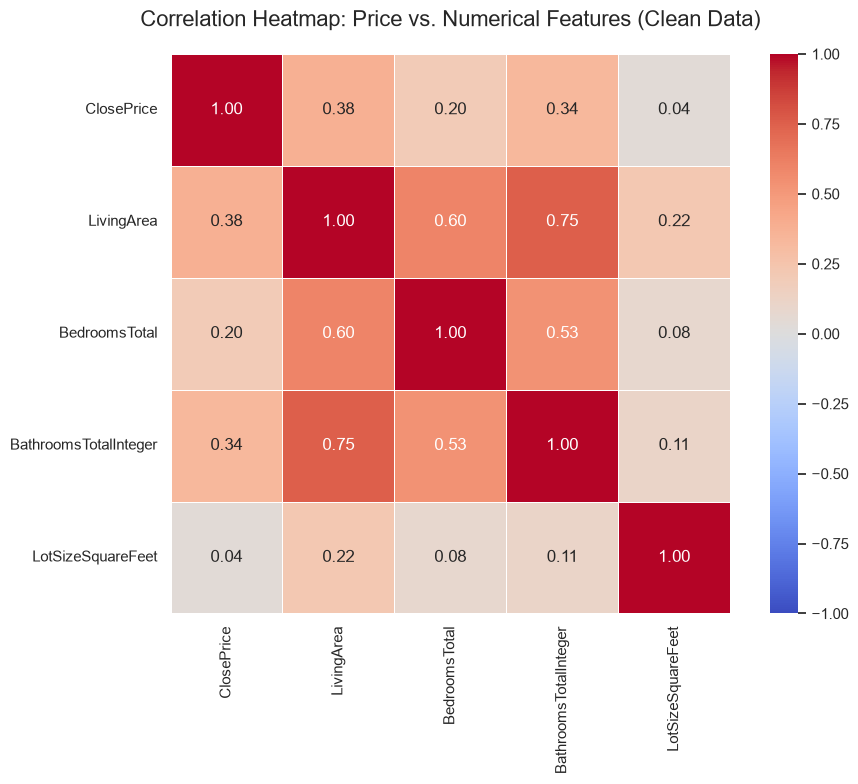

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 把目标变量(ClosePrice)和四大特征放在一起
cols_to_analyze = ['ClosePrice', 'LivingArea', 'BedroomsTotal', 
                   'BathroomsTotalInteger', 'LotSizeSquareFeet']

# 2. ⭐️ 核心修复：用刚洗干净的 df_clean 跑相关性！
# 此时数据已经去除了极端的豪宅和老破小，全是核心中产房源
corr_matrix = df_clean[cols_to_analyze].corr()

# 3. 画出高大上的热力图
plt.figure(figsize=(10, 8))
sns.set_theme(style="white")

# 使用 coolwarm 渐变色，越红代表正相关越强，越蓝代表负相关
sns.heatmap(corr_matrix, 
            annot=True,          # 在格子里显示具体数字
            fmt=".2f",           # 保留两位小数
            cmap="coolwarm",     # 红蓝配色
            vmin=-1, vmax=1,     # 相关系数范围是 -1 到 1
            linewidths=0.5, 
            square=True)

plt.title('Correlation Heatmap: Price vs. Numerical Features (Clean Data)', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

### Core Business Insights and Modeling Outlook (Business Insights & Modeling Strategy)

**1. Pricing Logic and Market Positioning of the Target Variable (ClosePrice)**
- **Distribution Anomalies and Transformation Logic**: Real estate pricing in California exhibits a strong “multiplier effect” (where a very small number of top-tier luxury homes severely skew the mean), resulting in a severely right-skewed price distribution. Applying a logarithmic (Log) transformation is not only a statistical requirement but also serves to restore the underlying business pricing logic of the real market, where prices fluctuate “proportionally (rather than by absolute values).”
- **Business Rationale Behind the 5% Truncation**: Truncating the top and bottom 5% of home price data is a deliberate “product strategy trade-off.” The goal is to exclude “foreclosure properties (extremely low)” and “exceptional top-tier luxury homes (extremely high)”—which are difficult to explain using standard logic—and to focus the model’s predictive power entirely on the core California middle-class homebuyer market.

**2. Standardization and Restructuring of Core Features (Numerical Features)**
- **The Fundamental Reason for Truncation**: Applying the same 5% truncation to features such as square footage, number of bedrooms, and number of bathrooms is primarily intended to forcibly filter out “extreme data entry errors” (e.g., 175 bathrooms) and “non-standard properties” (e.g., small farms or hotels mistakenly classified as single-family homes) at the operational level.
- **Establishing a Standard Baseline**: This multidimensional, interconnected truncation essentially creates a “safe sandbox” of “standard California residences” for the algorithm, ensuring that subsequent models learn pure, highly universal market supply-and-demand patterns rather than noise contaminated by extreme outliers.

**3. Breakdown of Core Drivers (Heatmap Insights) and Model Risks**
- **Pricing Anchors and Hidden Variables**: “Interior floor area” is currently the strongest physical anchor driving up housing prices; however, “land area” shows almost zero correlation with price (0.04). From a business perspective, this strongly suggests that “land size only holds value when combined with geographic location” (hundreds of mu in the desert are worth less than a small courtyard in Silicon Valley), clearly indicating that subsequent feature engineering must incorporate the “zip code/city” dimension.
- **Hidden Algorithmic Risks (Potential Pitfalls)**: There is an extremely high positive correlation (0.75) between total area and the number of bathrooms. While this reflects the common-sense reality that “larger homes typically have more bathrooms,” at the algorithmic level, it triggers dangerous “multicollinearity.” If this data is fed directly into a linear model without proper handling, the predictive weights of these two features will conflict with each other, leading to extreme distortion; subsequent steps must therefore consider feature merging or dimensionality reduction.

Translated with DeepL.com (free version)